<a href="https://colab.research.google.com/github/tashfiyamel-blip/POST-TEST-PRAKTIKUM-ALGORITMA-DAN-PEMROGRAMAN/blob/main/Grafik_4_(Kategori_4).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_2126/3342789108.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2126/3342789108.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=8.5)


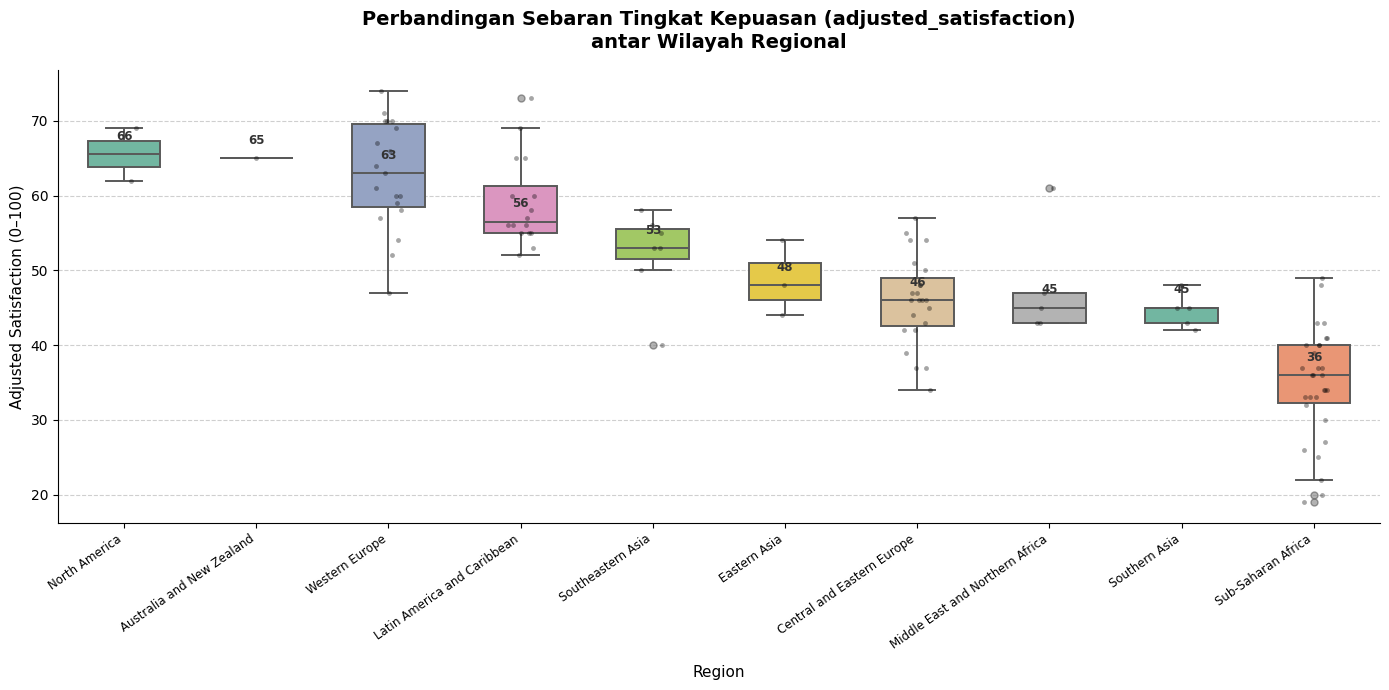

Plot berhasil disimpan: boxplot_satisfaction_by_region.png


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── 1. Load data ──────────────────────────────────────────────────────────────
df = pd.read_csv(
    "/content/Kelas D_Happiness and Satisfaction.csv",
    sep=";",
    decimal=","
)

# Bersihkan nama kolom & strip kutip di kolom Region
df.columns = df.columns.str.strip()
df["Region"] = df["Region"].str.strip().str.strip("'")

# Pastikan kolom target numerik
df["adjusted_satisfaction (0-100)"] = pd.to_numeric(
    df["adjusted_satisfaction (0-100)"], errors="coerce"
)
df.dropna(subset=["adjusted_satisfaction (0-100)", "Region"], inplace=True)

# ── 2. Urutkan region berdasarkan median (descending) ─────────────────────────
region_order = (
    df.groupby("Region")["adjusted_satisfaction (0-100)"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

# ── 3. Warna per region ───────────────────────────────────────────────────────
palette = sns.color_palette("Set2", n_colors=len(region_order))

# ── 4. Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))

sns.boxplot(
    data=df,
    x="Region",
    y="adjusted_satisfaction (0-100)",
    order=region_order,
    palette=palette,
    width=0.55,
    linewidth=1.4,
    flierprops=dict(marker="o", markersize=5, linestyle="none",
                    markerfacecolor="gray", alpha=0.6),
    ax=ax
)

# Tambahkan strip-plot agar titik data terlihat
sns.stripplot(
    data=df,
    x="Region",
    y="adjusted_satisfaction (0-100)",
    order=region_order,
    color="black",
    size=3.5,
    alpha=0.35,
    jitter=True,
    ax=ax
)

# ── 5. Anotasi median di atas tiap box ────────────────────────────────────────
for i, region in enumerate(region_order):
    median_val = df[df["Region"] == region]["adjusted_satisfaction (0-100)"].median()
    ax.text(i, median_val + 1.5, f"{median_val:.0f}",
            ha="center", va="bottom", fontsize=8.5, fontweight="bold", color="#333")

# ── 6. Estetika ───────────────────────────────────────────────────────────────
ax.set_title(
    "Perbandingan Sebaran Tingkat Kepuasan (adjusted_satisfaction)\nantar Wilayah Regional",
    fontsize=14, fontweight="bold", pad=16
)
ax.set_xlabel("Region", fontsize=11, labelpad=10)
ax.set_ylabel("Adjusted Satisfaction (0–100)", fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=8.5)
ax.yaxis.grid(True, linestyle="--", alpha=0.6)
ax.set_axisbelow(True)
sns.despine(left=False, bottom=False)

plt.tight_layout()
plt.savefig("boxplot_satisfaction_by_region.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot berhasil disimpan: boxplot_satisfaction_by_region.png")